1.- Crea un dataset aleatorio formado por un array de 1000 instancias de datos de dimensión 8, las etiquetas correspondientes estarán en un array con los valores de clase 0 a 5 (enteros aleatorios)

In [ ]:
import numpy as np

# Definimos las dimensiones
n_instancias = 1000
dimension = 8

# Creamos los datos (X): 1000 filas y 8 columnas con valores aleatorios
X = np.random.rand(n_instancias, dimension)

# Creamos las etiquetas (y): valores enteros entre 0 y 5 (inclusive)
# Nota: np.random.randint el límite superior es exclusivo, por eso usamos 6
y = np.random.randint(0, 6, size=n_instancias)

print(f"Forma de X: {X.shape}") # (1000, 8)
print(f"Forma de y: {y.shape}") # (1000,)

Forma de X: (1000, 8)
Forma de y: (1000,)


2.- Haz un muestreo sin reemplazo que reduzca a 60 el tamaño del dataset anterior. En él, deben de estar equilibradas las clases en cuanto a numero de instancias. Debes de conservar en otro array las etiquetas correspondientes.

In [ ]:
import numpy as np

n_clases = 6
muestras_por_clase = 10  # 60 total / 6 clases
indices_finales = []

for clase in range(n_clases):
    # Buscamos dónde están las instancias de esta clase específica
    indices_de_esta_clase = np.where(y == clase)[0]

    # Elegimos 10 al azar sin reemplazo
    seleccion = np.random.choice(indices_de_esta_clase, size=muestras_por_clase, replace=False)

    # Guardamos los índices elegidos
    indices_finales.extend(seleccion)

# Creamos los nuevos arrays usando los índices seleccionados
X_reducido = X[indices_finales]
y_reducido = y[indices_finales]

# Mezclamos el resultado final para que no queden ordenados por clase
permuta = np.random.permutation(len(y_reducido))
X_reducido = X_reducido[permuta]
y_reducido = y_reducido[permuta]

print(f"Resultado: {len(y_reducido)} muestras totales, equilibradas")

Resultado: 60 muestras totales, equilibradas


3.- Carga en un array numpy la imagen:


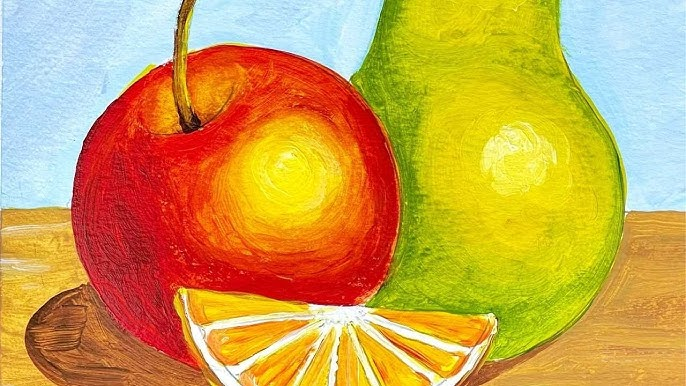

Utiliza el algoritmo k-means sobre este array para segmentar la imagen.
Pasos:
La componente RGB serán las características de entrada.

Estima un k para el algoritmo basandote en los colores que aprecies en la imagen.

Crea un array de colores básicos de tamaño k.

Sustituye en la imagen el valor de Rgb por estos colores básicos según cada clase obtenida en k-means.

Muestra la nueva imagen


Dimensiones correctas: 386x686 con 3 canales


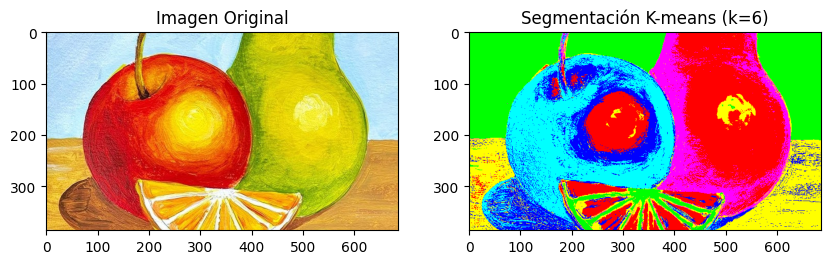

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from PIL import Image

# Cargamos la imagen asegurando 3 canales (RGB)
img = Image.open('/content/sample_data/frutas.png').convert('RGB')
img_array = np.array(img)

# Guardamos las dimensiones
alto, ancho, canales = img_array.shape
print(f"Dimensiones correctas: {alto}x{ancho} con {canales} canales")

# Preparamos los datos (características de entrada)
# Aplanamos la imagen: de (alto, ancho, 3) a (alto*ancho, 3)
pixeles = img_array.reshape(-1, 3)

# Estimamos la K y aplicamos K-means
# Mirando la imagen, apreciamos unos 5-6 colores principales:
# Rojo, Verde, Naranja, Amarillo, Fondo claro y Sombras
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
etiquetas = kmeans.fit_predict(pixeles)

# Creamos array de colores básicos
# Definimos colores llamativos como en tu imagen de ejemplo (RGB)
colores_basicos = np.array([
    [255, 0, 0],     # Rojo
    [0, 255, 0],     # Verde
    [0, 0, 255],     # Azul
    [255, 255, 0],   # Amarillo
    [255, 0, 255],   # Magenta
    [0, 255, 255]    # Cian
])

# Sustituimos cada píxel por su color básico correspondiente
# Cada etiqueta (0 a k-1) se convierte en uno de los colores del array
pixeles_segmentados = colores_basicos[etiquetas]

# Reconstruimos y mostramos la imagen
img_final = pixeles_segmentados.reshape(alto, ancho, 3)

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.title("Imagen Original")
plt.imshow(img_array)

plt.subplot(1, 2, 2)
plt.title(f"Segmentación K-means (k={k})")
plt.imshow(img_final)
plt.show()

In [ ]:
#RESULTADO ORIENTATIVO

4.- Crea un agente que use un modelo Ollama "ministral-3:14b" . Desarrolla una tool que pregunte al usuario una clave de acceso para menores, cuando el usuario mencione un tema relacionado con la violencia. Si la clave es válida se contestará a la pregunta.

In [ ]:
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.agents import create_tool_calling_agent, AgentExecutor

# 1. Definimos la herramienta (Tool)
# El docstring (texto entre comillas triples) es CRUCIAL, ya que le dice al LLM cuándo usarla.
@tool
def verificar_clave_acceso() -> str:
    """
    USA ESTA HERRAMIENTA OBLIGATORIAMENTE Y DE INMEDIATO siempre que el usuario mencione
    temas relacionados con violencia, daño, armas o contenido inapropiado para menores.
    Esta herramienta pide la clave parental al usuario.
    """
    print("\n[Sistema] Tema sensible detectado. Pausando ejecución...")
    clave = input("Por favor, introduce la clave de acceso para adultos: ")

    # Aquí definimos la clave válida (ejemplo: '1234')
    if clave == "1234":
        return "ÉXITO: La clave es correcta. Responde a la pregunta original del usuario de forma detallada."
    else:
        return "ERROR: La clave es incorrecta o no ha sido proporcionada. Dile al usuario que no tienes permiso para hablar de este tema."

# 2. Configuramos el LLM con Ollama
llm = ChatOllama(
    model="ministral-3:14b", # El modelo que has especificado
    temperature=0.2          # Temperatura baja para que sea más determinista con las tools
)

# 3. Preparamos las herramientas y el prompt del Agente
tools = [verificar_clave_acceso]

prompt = ChatPromptTemplate.from_messages([
    ("system", "Eres un asistente de IA útil. Si el usuario te pregunta sobre violencia, "
               "DEBES llamar a la herramienta 'verificar_clave_acceso' antes de responder. "
               "Sigue estrictamente las instrucciones que te devuelva la herramienta."),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

# 4. Creamos el agente y el ejecutor
agent = create_tool_calling_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

# 5. Bucle de conversación
def iniciar_chat():
    print("🤖 Agente iniciado. (Escribe 'salir' para terminar)")
    while True:
        pregunta = input("\nTú: ")
        if pregunta.lower() in ['salir', 'exit']:
            break

        # Ejecutamos el agente
        respuesta = agent_executor.invoke({"input": pregunta})
        print(f"\n🤖 Agente: {respuesta['output']}")

if __name__ == "__main__":
    iniciar_chat()